In [2]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv('data/bank.csv')
df=pd.DataFrame(data)
df.head()
df=df.drop_duplicates()

#### 예측 모델링

- 목표변수 y(정기 예금 가입여부)를 예측하기 위한 분류모델을 생성하고 평가한다.

In [4]:
X=df.drop(columns=['y'],axis=1)
y=df['y']

In [5]:
X.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown


In [6]:
y.head(5)

0    no
1    no
2    no
3    no
4    no
Name: y, dtype: object

In [7]:
X.query('pdays != -1').pdays.describe()

count    8257.000000
mean      224.577692
std       115.344035
min         1.000000
25%       133.000000
50%       194.000000
75%       327.000000
max       871.000000
Name: pdays, dtype: float64

In [8]:
def pdays_category(pdays):
    if pdays == -1:
        return '연락x'
    elif pdays <= 100:
        return '100일 이내'
    elif pdays <= 200:
        return '200일 이내'
    elif pdays <= 300:
        return '300일 이내'
    else:
        return '300일 초과'
    
X['pdays_cat'] = X['pdays'].apply(pdays_category)
X[['pdays', 'pdays_cat']].head(5) 

,pdays,pdays_cat
0,-1,연락x
1,-1,연락x
2,-1,연락x
3,-1,연락x
4,-1,연락x


In [9]:
X = X.drop('pdays', axis=1)
X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,previous,poutcome,pdays_cat
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,0,unknown,연락x
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,0,unknown,연락x
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,0,unknown,연락x
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,0,unknown,연락x
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,0,unknown,연락x


In [10]:
y = y.apply(lambda x: 1 if x == 'yes' else 0)  # 정기 예금 가입자 = 1, 비가입자 = 0
y.head()

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64

In [11]:
categorical_list = X.select_dtypes(include='object').columns.tolist()  # 문자열로 되어 있는, 범주형 데이터를 담고 있는 컬럼만 골라냅니다.
print(categorical_list)

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'pdays_cat']


In [12]:
X_encoded = pd.get_dummies(X, columns=categorical_list,  # 대상이 되는 컬럼을 리스트 형태로 'columns' 파라미터에 넣어 줍니다.
                           dtype='int')  # boolean 형태 대신 0, 1의 숫자형으로 반환해 주겠다는 의미입니다.

X_encoded.head()

,age,balance,day,campaign,previous,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,pdays_cat_100일 이내,pdays_cat_200일 이내,pdays_cat_300일 이내,pdays_cat_300일 초과,pdays_cat_연락x
0,58,2143,5,1,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,44,29,5,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,33,2,5,1,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
3,47,1506,5,1,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,33,1,5,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [13]:
X_encoded.columns

Index(['age', 'balance', 'day', 'campaign', 'previous', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'default_no', 'default_yes', 'housing_no',
       'housing_yes', 'loan_no', 'loan_yes', 'contact_cellular',
       'contact_telephone', 'contact_unknown', 'month_apr', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown', 'pdays_cat_100일 이내', 'pdays_cat_200일 이내',
       'pdays_cat_300일 이내', 'pdays_cat_300일 초과', 'pdays_cat_연락x'],
      dtype='object')

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

In [15]:
# 7:3으로 잘 분할되었는지 확인합니다.
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(31636, 54)
(13559, 54)
(31636,)
(13559,)


In [16]:
from sklearn.ensemble import RandomForestClassifier

model_Rand_1 = RandomForestClassifier(random_state=42)

model_Rand_1.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [17]:
from sklearn.metrics import classification_report

y_pred_test = model_Rand_1.predict(X_test)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     11944
           1       0.63      0.24      0.34      1615

    accuracy                           0.89     13559
   macro avg       0.77      0.61      0.64     13559
weighted avg       0.87      0.89      0.87     13559



#### [classification_report 읽는 법]

- 클래스 0은 정기예금 비가입자를 의미하며, 클래스 1은 정기예금 가입자를 의미합니다.
- `precision`: 모델이 True로 분류한 데이터 중 실제로 True인 데이터의 비율입니다. 클래스 0의 경우 91%, 클래스 1의 경우 63%로, 이는 모델의 클래스 0에 대한 예측력이 클래스 1보다 높음을 의미합니다.
- `recall`: 실제로 True에 속한 데이터 중 모델이 True로 분류한 데이터의 비율입니다. 클래스 0의 경우 98%, 클래스 1의 경우 24%로, 클래스 0은 precision보다 recall이, 클래스 1은 반대로 recall보다 precision이 높게 나타나고 있습니다. 실제로는 0인데 모델이 1로 분류하는 데이터보다 실제로는 1인데 모델이 0으로 분류하는 데이터가 많기 때문에 이런 현상이 나타나는 것으로 보입니다.
    - 참고로 `support`는 해당 클래스에 속하는 실제 데이터의 수를 의미합니다. 이를 보면 실제로 0에 속하는 데이터가 훨씬 많기 때문에, 모델이 '애매할 때는 0으로 분류하는 편이 정답 확률이 높다'고 인식하고 1보다는 0이라는 예측값을 더 자주 부여하고 있는 것이라 추측해 볼 수 있습니다.
- `f1-score`: precision과 recall의 조화 평균으로, 두 값을 균형 있게 반영한 점수입니다. 클래스 0의 경우 94%, 클래스 1의 경우 35%로, 모델이 클래스 0은 비교적 정확하게 예측하고 있으나 클래스 1의 예측에는 어려움을 겪고 있다고 해석할 수 있습니다.
- `accuracy`: 전체 데이터 중 실제 값으로 올바르게 예측된 데이터의 비율입니다. 본 모델은 전체 데이터의 89%가 정확하게 예측되었으나, 사실 이 데이터셋은 y값의 불균형이 크기 때문에(= 클래스 0이 훨씬 많기 때문에) accuracy만으로 모델의 성능을 평가하기보다는 각 클래스별 f1-score를 함께 고려하는 편이 좋습니다.
- `macro avg`, `weighted_avg`: macro avg는 위의 클래스별 값을 단순 평균 낸 개념이며, weighted avg는 각 클래스에 속하는 데이터의 개수를 반영해 가중 평균을 낸 개념입니다.

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[100,200], # 생성할 트리의 개수
    'max_depth':[None,10,20], # 트리의 최대 깊이
    'class_weight':[None,'balanced','balanced_subsample'] # 클래스별 가중치를 둬서 클래스 불균형을 다루는 방법
}

model_Rand_grid=RandomForestClassifier()

grid_search=GridSearchCV(model_Rand_grid, param_grid, scoring='f1', cv=3)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

Best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 200}


In [19]:
model_Rand_best=grid_search.best_estimator_
model_Rand_best.fit(X_train, y_train)
y_pred_test = model_Rand_best.predict(X_test)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.94      0.84      0.89     11944
           1       0.34      0.59      0.43      1615

    accuracy                           0.81     13559
   macro avg       0.64      0.72      0.66     13559
weighted avg       0.87      0.81      0.83     13559



/tmp/ipykernel_13212/1925106645.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ftr_top10, y=ftr_top10.index, palette='Blues_r')
/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/woojuyee/ML_projects/day6_bank/.

<Axes: title={'center': 'Feature Importances - Top 10'}, xlabel='None', ylabel='None'>

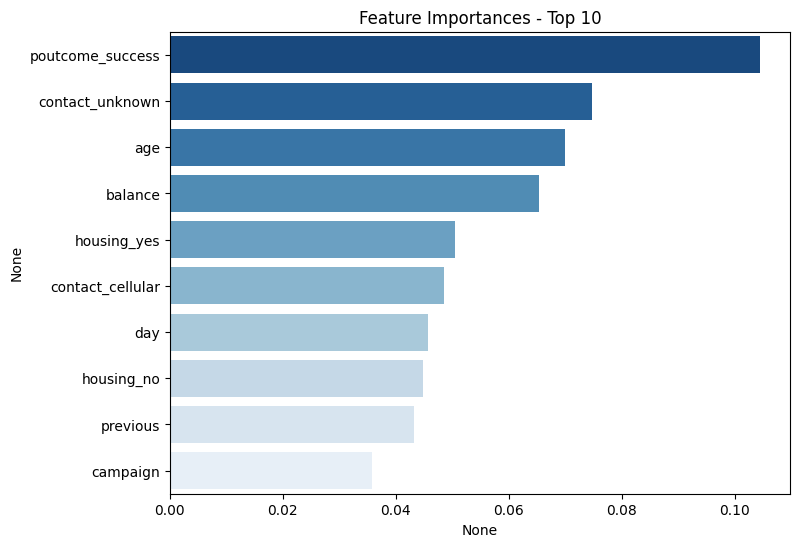

In [20]:
ftr_imp_values=model_Rand_best.feature_importances_
ftr_importances = pd.Series(ftr_imp_values, index=X_train.columns)
ftr_top10=ftr_importances.sort_values(ascending=False)[:10]

plt.figure(figsize=(8,6))
plt.title('Feature Importances - Top 10')
sns.barplot(x=ftr_top10, y=ftr_top10.index, palette='Blues_r')

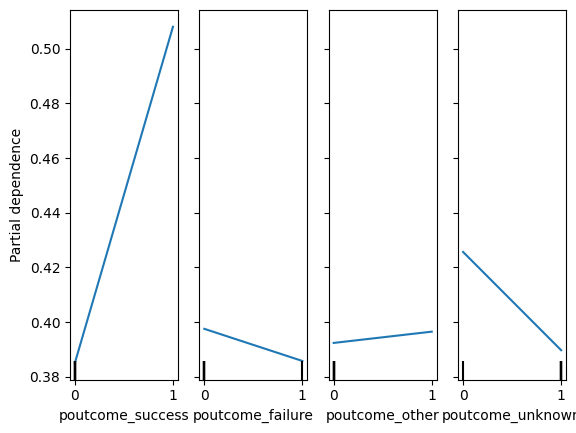

In [21]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(model_Rand_best, X_train,  # 학습된 모델과 X값을 넣어 줍니다.
                                        features=['poutcome_success', 'poutcome_failure', 'poutcome_other', 'poutcome_unknown'],  # list 안에 확인할 대상이 되는 입력변수의 정보를 넣어 줍니다.
                                        n_cols=4,  # 그래프에 최대 몇 개까지의 열을 허용할 것인지에 대한 값입니다. default는 3이며, 이 경우 네 개의 변수를 비교해 보고 싶으므로 4로 설정해 주었습니다.
                                        kind='average',  # default 값이 'average'이며, 이는 데이터셋에 있는 모든 샘플에 대한 partial dependence 수치를 평균 내어 보여주겠다는 의미입니다.
                                                         # kind='individual'로 설정하면 모든 샘플의 값을 다 보여주는 ICE plot이 그려집니다.
)

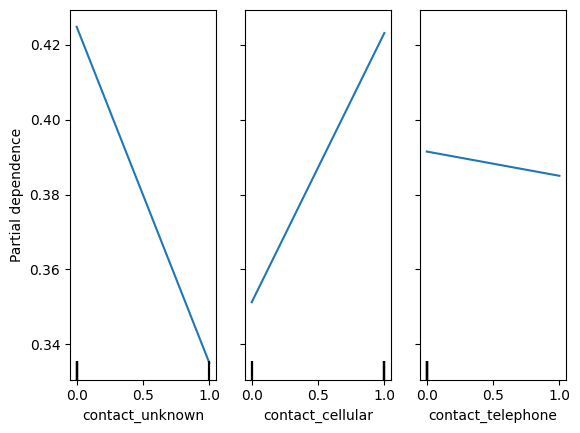

In [22]:
PartialDependenceDisplay.from_estimator(model_Rand_best, X_train, features=['contact_unknown', 'contact_cellular', 'contact_telephone'],  kind='average');

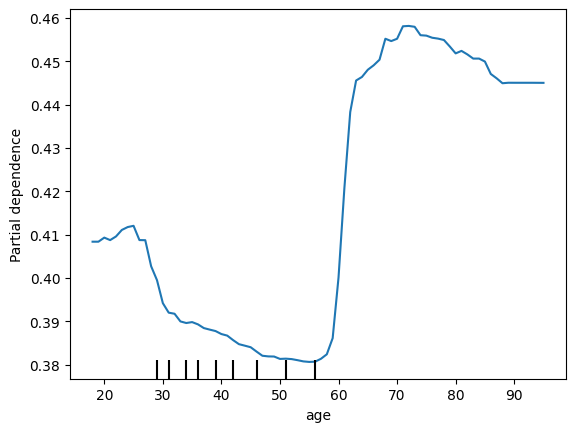

In [23]:
PartialDependenceDisplay.from_estimator(model_Rand_best, X_train, features=['age'],  kind='average')

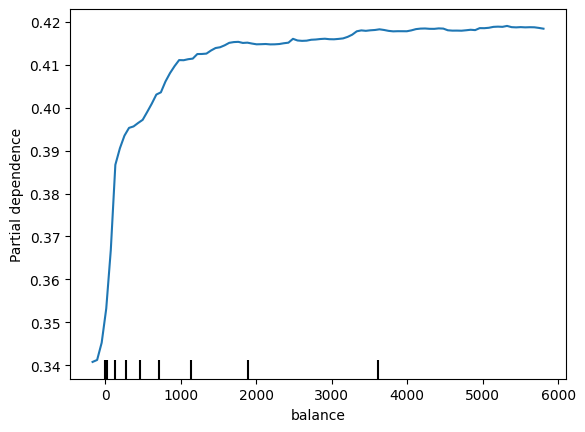

In [24]:
PartialDependenceDisplay.from_estimator(model_Rand_best, X_train, features=['balance'],  kind='average')

#### 타모델 사용

In [25]:
y_pred_test_rand_best = model_Rand_best.predict(X_test)
print(classification_report(y_test, y_pred_test_rand_best))
y_prob_rf = model_Rand_best.predict_proba(X_test)[:, 1]  # positive 클래스(1)에 대한 예측 확률값만 추출합니다.

              precision    recall  f1-score   support

           0       0.94      0.84      0.89     11944
           1       0.34      0.59      0.43      1615

    accuracy                           0.81     13559
   macro avg       0.64      0.72      0.66     13559
weighted avg       0.87      0.81      0.83     13559



In [26]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000, random_state=42) # max_iter=1000 옵션을 넣어주어 최대 반복 횟수를 늘려줍니다.
model_lr.fit(X_train, y_train)

y_pred_test_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_test_lr))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94     11944
           1       0.67      0.18      0.28      1615

    accuracy                           0.89     13559
   macro avg       0.78      0.58      0.61     13559
weighted avg       0.87      0.89      0.86     13559



/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)
model_xgb.fit(X_train, y_train)

# 학습된 XGBoost 모델로 예측
y_pred_xgb = model_xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

              precision    recall  f1-score   support

           0       0.91      0.98      0.94     11944
           1       0.60      0.27      0.37      1615

    accuracy                           0.89     13559
   macro avg       0.75      0.62      0.66     13559
weighted avg       0.87      0.89      0.87     13559



/home/woojuyee/ML_projects/day6_bank/.venv/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [12:11:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 각 모델의 성능 지표 계산
metrics = []
for name, y_pred, y_prob in [
    ("Logistic Regression", y_pred_test_lr, y_prob_lr),
    ("Random Forest", y_pred_test_rand_best, y_prob_rf),
    ("XGBoost", y_pred_xgb, y_prob_xgb)
]:
    metrics.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# 결과를 표 형태로 출력
df_metrics = pd.DataFrame(metrics)
print(df_metrics.to_string(index=False))


              Model  Accuracy  Precision   Recall       F1  ROC-AUC
Logistic Regression  0.891511   0.669811 0.175851 0.278568 0.765758
      Random Forest  0.812966   0.336760 0.588235 0.428314 0.793745
            XGBoost  0.891659   0.601671 0.267492 0.370339 0.792512
